``` text
Description: Data analysis of NX-NS dynamics after pre-treatment with Ulamdyn.  
Author: M. Casal
Date: 06/03/2026

It requires a previous Ulamdyn run:
run-ulamdyn --source nxns_txt \  
            --save_dataset coordinates \  
            --save_dataset r2 \  
            --bootstrap=10000 \  
            --create_stats all \  
               nma   
It plots:
   Histogram:
      - RMSD distribution
      - Energy gaps
      - Hops distribution
   Line plots:
      Index dependent (it should be changed manually):
      - Bond length betwee specific atoms.
      - Dihedral angles
      - Mean bond length
   General:
      - Mean population
      - Mean oscillator strength
      - Mean DeltaE between excited states
      - Normal mode analysis 

Variables that should be changed manually:
   label: it will be appended to the beginning of file's name
   atom indexes: the atom index to be used in the bond length plots

Output:
   All plots are going to be store inside of the "plots" directory. 
```

# Setup

In [ ]:
# General libraries
import numpy as np
import pandas as pd
import ulamdyn as umd

# Data fitting
from scipy.optimize import curve_fit

# Plotting libraries
import py3Dmol
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# System
from pathlib import Path
import os

In [ ]:
label='4-ic-4.0-4.5_'

# Setting up plots directory
plot_dir = Path("plots")
if not plot_dir.exists():
    plot_dir.mkdir()

In [6]:
%matplotlib inline

mpl.rcParams['figure.figsize'] = [6,6]
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 16


# plt.style.use('seaborn-white')
sns.set(color_codes=True)

legend_settings = {'loc':'upper center', 'ncol':3, 'frameon':True, 'facecolor':'white',
                   'framealpha':0.8, 'bbox_to_anchor':(0.5, 1.11)}

# Functions

In [7]:
def view_molecule(xyz_geom, style):

    for k in style.keys():
        assert k in ('line', 'stick', 'sphere', 'carton')

    molview = py3Dmol.view(width=350,height=350)
    molview.addModel(xyz_geom,'xyz')

    molview.setStyle(style)
    molview.setBackgroundColor('white')
    molview.zoomTo()
    molview.addPropertyLabels('index')
    
    
    return molview

s = {'stick': {'radius': .15}, 'sphere': {'scale': 0.20}}

In [8]:
def plot_hist(values, x_label, y_label, save=False, name='histogram'):
    fig, ax = plt.subplots()

    hist = plt.hist(values, bins=50, alpha=0.8, color='steelblue', edgecolor='black')

    # White background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.5)


    # Ticks: black, inward, thicker
    ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)

    # Labels with larger font
    ax.set_xlabel(x_label, fontsize=14, color='black')
    ax.set_ylabel(y_label, fontsize=14, color='black')

    # Tick label size
    ax.tick_params(labelsize=12)

    # Tight layout for publication
    plt.tight_layout()
    
    plt.savefig('plots/'+name, dpi=300) if save else None
    plt.show()


In [9]:
def dihedral(p1, p2, p3, p4):
    """
    Compute a dihedral angle (degrees) from four Cartesian points.
    """
    b1 = p2 - p1
    b2 = p3 - p2
    b3 = p4 - p3

    b2 /= np.linalg.norm(b2)

    v = b1 - np.dot(b1, b2) * b2
    w = b3 - np.dot(b3, b2) * b2

    x = np.dot(v, w)
    y = np.dot(np.cross(b2, v), w)

    return np.degrees(np.arctan2(y, x))


def compute_dihedral_per_row(df, a1, a2, a3, a4):
    """
    Compute dihedral angle per row (per time step, per trajectory).

    Atom indices are 1-based (x1,y1,z1,...).
    Returns a NumPy array aligned with df rows.
    """
    angles = np.empty(len(df))

    for i, row in df.iterrows():
        p1 = row[[f"x{a1}", f"y{a1}", f"z{a1}"]].to_numpy()
        p2 = row[[f"x{a2}", f"y{a2}", f"z{a2}"]].to_numpy()
        p3 = row[[f"x{a3}", f"y{a3}", f"z{a3}"]].to_numpy()
        p4 = row[[f"x{a4}", f"y{a4}", f"z{a4}"]].to_numpy()

        angles[i] = dihedral(p1, p2, p3, p4)

    return angles

# CSV Files

run-ulamdyn --source nxns_txt --save_dataset coordinates --save_dataset r2   
            
    
run-ulamdyn --source nxns_txt --bootstrap=10000  
run-ulamdyn --source nxns_txt --create_stats all  
run-ulamdyn --source nxns_txt nma  
            

In [10]:
coords          = pd.read_csv('all_coordinates.csv')
coords_r2       = pd.read_csv('all_geoms_r2.csv')
props           = pd.read_csv('all_properties.csv')
pops            = pd.read_csv('stats_bootstrap.csv')
props_stats     = pd.read_csv('stats_properties.csv')
hops_stats      = pd.read_csv('stats_hoppings.csv')
coords_r2_stats = pd.read_csv('stats_r2.csv')
nma             = pd.read_csv('all_nma.csv')

# RMSD distribution

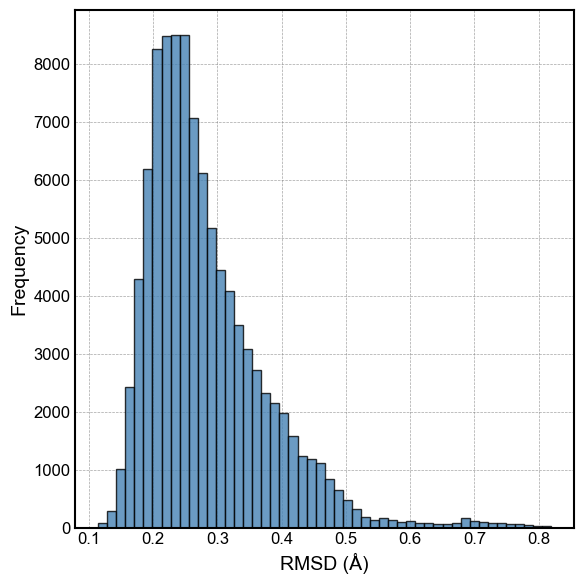

In [18]:
# RMSD DISTRIBUTION
plot_hist(coords['RMSD'], 'RMSD (Å)', 'Frequency', save=True, name=label+'rmsd_distribution.png')

# Energy gaps

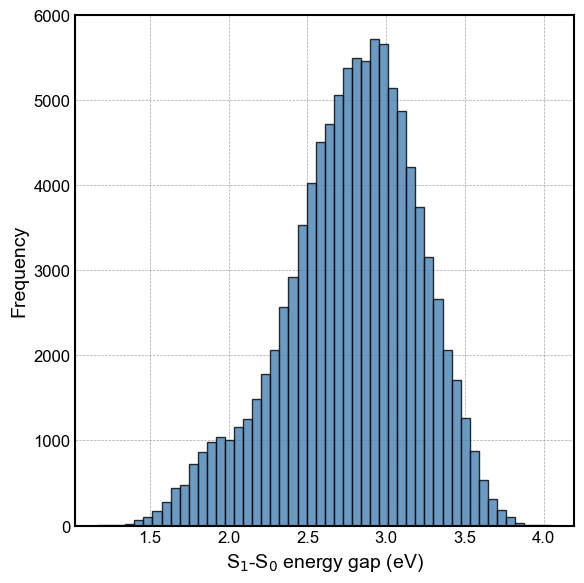

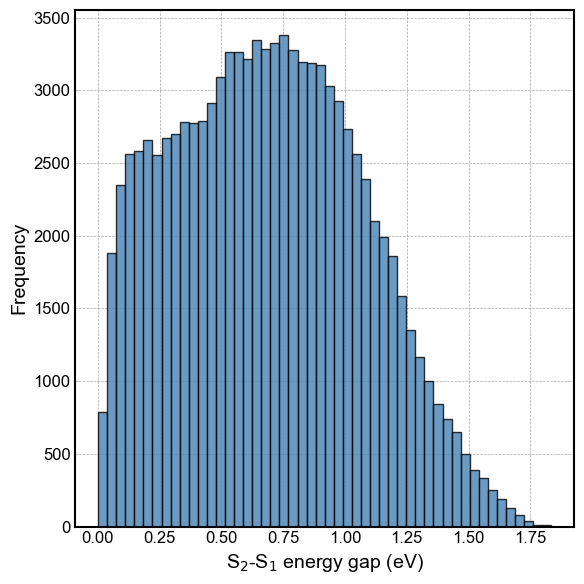

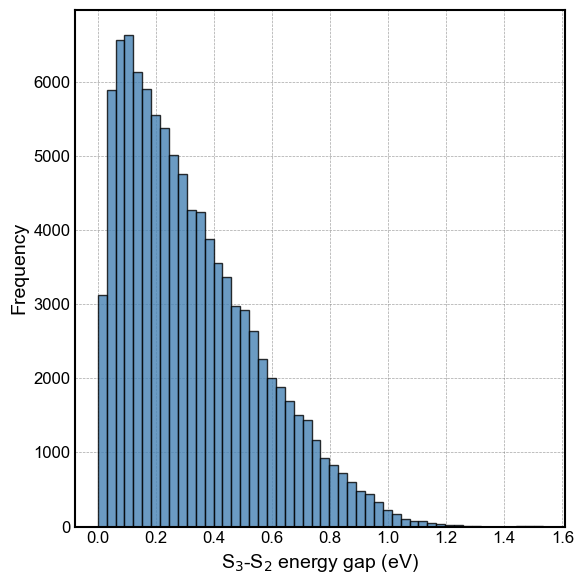

In [19]:
# ENERGY GAPS
gap_21 = props['DE2_1'].values
plot_hist(gap_21, "S$_1$-S$_0$ energy gap (eV)", "Frequency", save=True, name=label+'S1S0-gap-distribution.png')

gap_32 = props['DE3_2'].values
plot_hist(gap_32, "S$_2$-S$_1$ energy gap (eV)", "Frequency", save=True, name=label+'S2S1-gap-distribution.png' )

gap_43 = props['DE4_3'].values
plot_hist(gap_43, "S$_3$-S$_2$ energy gap (eV)", "Frequency", save=True, name=label+'S3S2-gap-distribution.png' )

# Hops distribution

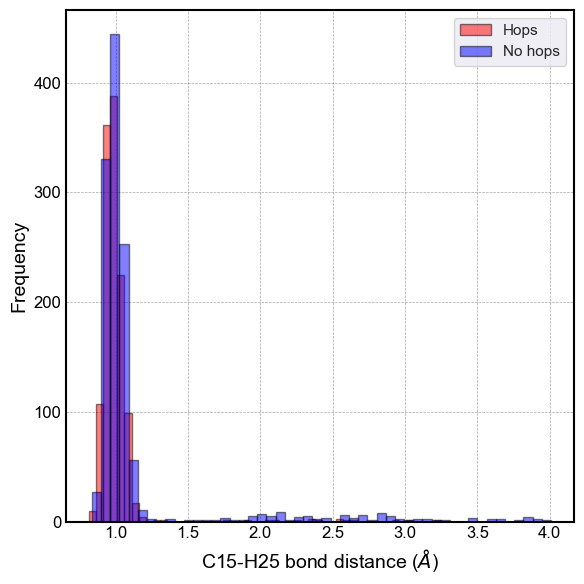

In [20]:
idx_all_hops = props.index[
    (props["Hops4_3"] == 1)
  | (props["Hops3_2"] == 1)
  | (props["Hops4_2"] == 1)
].tolist()

idx_no_hops = props.index[
    (props["Hops3_4"] == 0)
  & (props["Hops4_3"] == 0)
  & (props["Hops2_3"] == 0)
  & (props["Hops3_2"] == 0)
  & (props["Hops2_4"] == 0)
  & (props["Hops4_2"] == 0)
].tolist()

fig, ax = plt.subplots()

h1 = plt.hist(coords_r2.iloc[idx_all_hops]['r15_25'], bins=50, color='red', alpha=0.5, label='Hops', edgecolor='black')
h2 = plt.hist(coords_r2.iloc[idx_no_hops]['r15_25'].sample(len(idx_all_hops)), bins=50, color='blue', alpha=0.5, label='No hops', edgecolor='black'),

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)


# Ticks: black, inward, thicker
ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)

# Labels with larger font
ax.set_xlabel('C15-H25 bond distance ($\AA$)', fontsize=14, color='black')
ax.set_ylabel('Frequency', fontsize=14, color='black')

ax.tick_params(labelsize=12)
plt.legend()
plt.tight_layout()

plt.savefig('plots/'+label+'hops-c15-h25.png', dpi=300) 

# OH bond length

In [21]:
# idx_43_hops = props.index[props["Hops4_3"] == 1].tolist()

# xlabel = "Time (fs)"
# ylabel = "C17-C25 bond distance ($\AA$)"

# for traj in coords_r2['TRAJ'].unique():

#     # Slice once
#     traj_data = coords_r2[coords_r2['TRAJ'] == traj]
#     t = traj_data['Time'].values
#     c17_25_dist = traj_data['r17_25'].values

#     fig, ax = plt.subplots()

#     # White background
#     ax.set_facecolor('white')
#     fig.patch.set_facecolor('white')
#     ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

#     for spine in ax.spines.values():
#         spine.set_color('black')
#         spine.set_linewidth(1.5)

#     # Ticks styling
#     ax.tick_params(axis='both', colors='black',
#                    direction='in', length=6, width=1.5,
#                    labelsize=12)

#     ax.set_xlabel(xlabel, fontsize=14, color='black')
#     ax.set_ylabel(ylabel, fontsize=14, color='black')

#     ax.plot(t, c17_25_dist, c='k', lw=0.5)

#     ax.set_xlim(0, 1000)
#     ax.set_title(f"TRAJ {traj}")

#     plt.tight_layout()
#     plt.show()


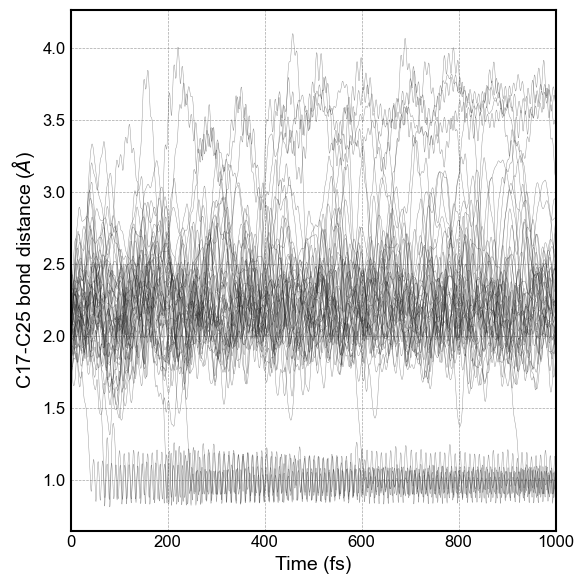

In [22]:
idx_43_hops = props.index[props["Hops4_3"] == 1].tolist()

xlabel = "Time (fs)"
ylabel = "C17-C25 bond distance ($\AA$)"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

# Ticks: black, inward, thicker
ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)

# Labels with larger font
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')

# Tick label size
ax.tick_params(labelsize=12)

for traj in coords_r2['TRAJ'].unique():
  t = coords_r2.query(f"TRAJ == {traj}")['Time'].values
  c15_h25_dist = coords_r2.query(f"TRAJ == {traj}")['r17_25'].values
  plt.plot(t, c15_h25_dist, c='k', lw=0.3, alpha=0.5)
# plt.scatter(coords_r2.iloc[idx_43_hops]['time'], coords_r2.iloc[idx_43_hops]['r1725'],
#             color='red', s=1.5)
plt.xlim(0,1000)
plt.tight_layout()
plt.show()

In [23]:
df_plot = coords_r2.join(props['State'])
df_plot[df_plot['Time'] == 1000]['State'].value_counts()

State
2    40
3     7
4     2
Name: count, dtype: int64

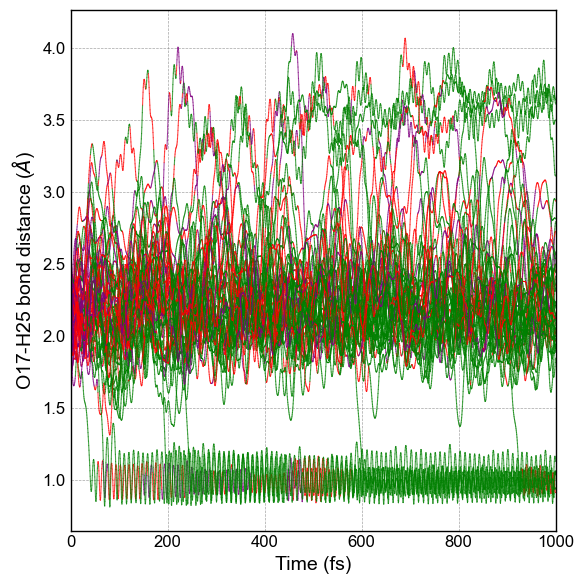

In [24]:
xlabel = "Time (fs)"
ylabel = "O17-H25 bond distance ($\AA$)"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'}  # adjust as needed

for traj in df_plot['TRAJ'].unique():
    
    
    
    traj_data = df_plot[df_plot['TRAJ'] == traj]
    t = traj_data['Time'].values
    c15_h25_dist = traj_data['r17_25'].values
    states = traj_data['State'].values
    plotted_states = set()  # to track which states have been labeled

    
    # Plot segment by segment to color according to state
    for i in range(len(t)-1):
        ax.plot(t[i:i+2], c15_h25_dist[i:i+2], 
                color=state_colors[states[i]], lw=0.8, alpha=0.7)

plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig('plots/'+label+'o17-h25-bond-time.png', dpi=300)
plt.show()

# O-C bond length

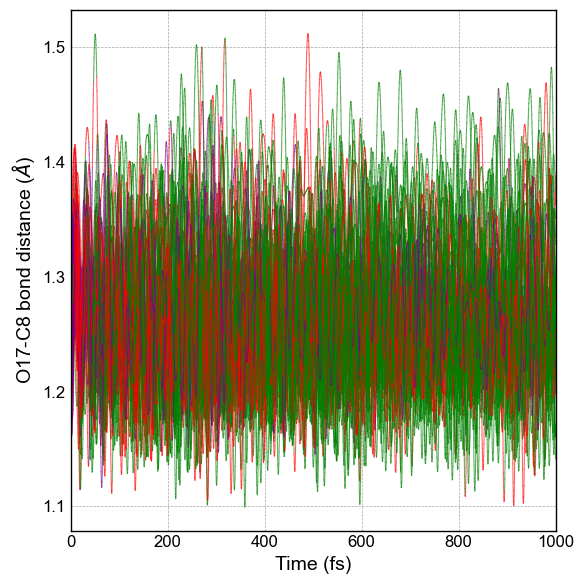

In [26]:
xlabel = "Time (fs)"
ylabel = "O17-C8 bond distance ($\AA$)"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'}  # adjust as needed

for traj in df_plot['TRAJ'].unique():
    
    
    
    traj_data = df_plot[df_plot['TRAJ'] == traj]
    t = traj_data['Time'].values
    c15_h25_dist = traj_data['r8_17'].values
    states = traj_data['State'].values
    plotted_states = set()  # to track which states have been labeled

    
    # Plot segment by segment to color according to state
    for i in range(len(t)-1):
        ax.plot(t[i:i+2], c15_h25_dist[i:i+2], 
                color=state_colors[states[i]], lw=0.8, alpha=0.6)

plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig('plots/'+label+'c17-c8-bond-time.png', dpi=300)
plt.show()

# Dihedral angles

In [27]:
# DIHEDRAL ANGLES
df_plot["d22.21.23.24_raw"] = compute_dihedral_per_row(coords, 22,21,23,24)
df_plot["d22.21.23.24"] = (df_plot["d22.21.23.24_raw"] + 360) % 360

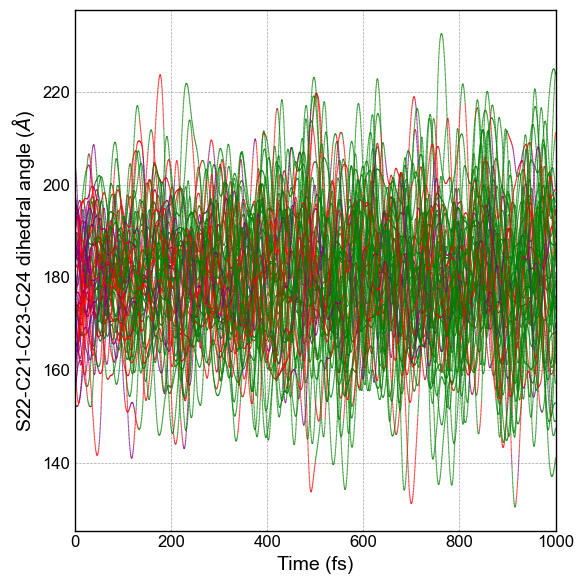

In [28]:
xlabel = "Time (fs)"
ylabel = "S22-C21-C23-C24 dihedral angle ($\AA$)"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'}  # adjust as needed

for traj in df_plot['TRAJ'].unique():
    
    traj_data = df_plot[df_plot['TRAJ'] == traj]
    t = traj_data['Time'].values
    c15_h25_dist = traj_data["d22.21.23.24"].values
    states = traj_data['State'].values
    plotted_states = set()  # to track which states have been labeled

    
    # Plot segment by segment to color according to state
    for i in range(len(t)-1):
        ax.plot(t[i:i+2], c15_h25_dist[i:i+2], 
                color=state_colors[states[i]], lw=0.8, alpha=0.6)

plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig('plots/'+label+'dihedral-time.png', dpi=300)
plt.show()

# Trajectories with O-H < 3

In [31]:
# How many trajectories reached regions where r1725 < 3 Å?

# Filter rows where r1525 > 3.0
filtered = coords_r2[coords_r2['r17_25'] > 3.0]

# Count unique TRAJs in that filtered set
count_trajs = filtered['TRAJ'].nunique()

print(f"Number of trajectories where C17-H25 distance exceeded 3 Å: {count_trajs} out of {coords_r2['TRAJ'].nunique()}")

# How many trajectories reached regions where r1725 > 1.45 Å?
filtered = coords_r2[coords_r2['r17_25'] < 1.45]
count_trajs = filtered['TRAJ'].nunique()
print(f"Number of trajectories where C17-H25 distance smaller than 1.45 Å: {count_trajs} out of {coords_r2['TRAJ'].nunique()}")



Number of trajectories where C17-H25 distance exceeded 3 Å: 31 out of 50
Number of trajectories where C17-H25 distance smaller than 1.45 Å: 11 out of 50


In [ ]:
# filtered = props[coords_r2['r17_25'] > 3.0]
filtered = props[props['Time'] == 1000]
n_trajs_state = filtered['State'].value_counts().tolist()
print(f" Number of trajectories at S1 at 1000 fs: {n_trajs_state[0]}" )
print(f" Number of trajectories at S2 at 1000 fs: {n_trajs_state[1]}" )
print(f" Number of trajectories at S3 at 1000 fs: {n_trajs_state[2]}" )

 Number of trajectories at S1 at 1000 fs: 40
 Number of trajectories at S2 at 1000 fs: 7
 Number of trajectories at S3 at 1000 fs: 2


# Mean Population

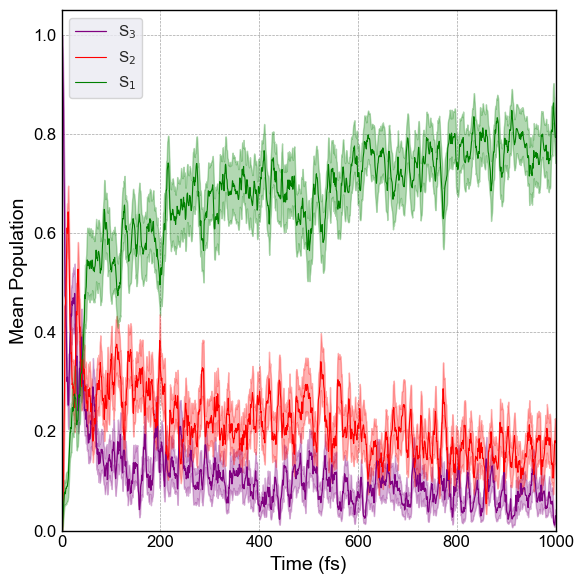

In [47]:
xlabel = "Time (fs)"
ylabel = "Mean Population"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'} 

 # Plot with standard deviation shaded area
ax.plot(pops['Time'], pops['Pop4_mean'], color=state_colors[4], lw=0.9, label='S$_3$')
ax.fill_between(pops['Time'],
                pops['Pop4_mean'] - pops['Pop4_std'],
                pops['Pop4_mean'] + pops['Pop4_std'],
                color=state_colors[4], alpha=0.3)

ax.plot(pops['Time'], pops['Pop3_mean'], color=state_colors[3], lw=0.8, label='S$_2$')
ax.fill_between(pops['Time'],
                pops['Pop3_mean'] - pops['Pop3_std'],
                pops['Pop3_mean'] + pops['Pop3_std'],
                color=state_colors[3], alpha=0.3)

ax.plot(pops['Time'], pops['Pop2_mean'], color=state_colors[2], lw=0.8, label='S$_1$')
ax.fill_between(pops['Time'],
                pops['Pop2_mean'] - pops['Pop2_std'],
                pops['Pop2_mean'] + pops['Pop2_std'],
                color=state_colors[2], alpha=0.3)

plt.xlim(0, 1000)
plt.ylim(bottom=0)
plt.tight_layout()
plt.legend()
plt.savefig('plots/'+label+'mean_pop-nostd.png', dpi=300)
plt.show()

# Mean oscillator strength

In [ ]:
# props_stats.columns.tolist()

['Time',
 'traj_count',
 'Etot_median',
 'Etot_mean',
 'Etot_std',
 'Etot_skew',
 'Etot_kurt',
 'Epot1_median',
 'Epot1_mean',
 'Epot1_std',
 'Epot1_skew',
 'Epot1_kurt',
 'DE2_1_median',
 'DE2_1_mean',
 'DE2_1_std',
 'DE2_1_skew',
 'DE2_1_kurt',
 'DE3_1_median',
 'DE3_1_mean',
 'DE3_1_std',
 'DE3_1_skew',
 'DE3_1_kurt',
 'DE3_2_median',
 'DE3_2_mean',
 'DE3_2_std',
 'DE3_2_skew',
 'DE3_2_kurt',
 'DE4_1_median',
 'DE4_1_mean',
 'DE4_1_std',
 'DE4_1_skew',
 'DE4_1_kurt',
 'DE4_2_median',
 'DE4_2_mean',
 'DE4_2_std',
 'DE4_2_skew',
 'DE4_2_kurt',
 'DE4_3_median',
 'DE4_3_mean',
 'DE4_3_std',
 'DE4_3_skew',
 'DE4_3_kurt',
 'Hops2_3_median',
 'Hops2_3_mean',
 'Hops2_3_std',
 'Hops2_3_skew',
 'Hops2_3_kurt',
 'Hops2_4_median',
 'Hops2_4_mean',
 'Hops2_4_std',
 'Hops2_4_skew',
 'Hops2_4_kurt',
 'Hops3_2_median',
 'Hops3_2_mean',
 'Hops3_2_std',
 'Hops3_2_skew',
 'Hops3_2_kurt',
 'Hops3_4_median',
 'Hops3_4_mean',
 'Hops3_4_std',
 'Hops3_4_skew',
 'Hops3_4_kurt',
 'Hops4_2_median',
 'Hops4_2_

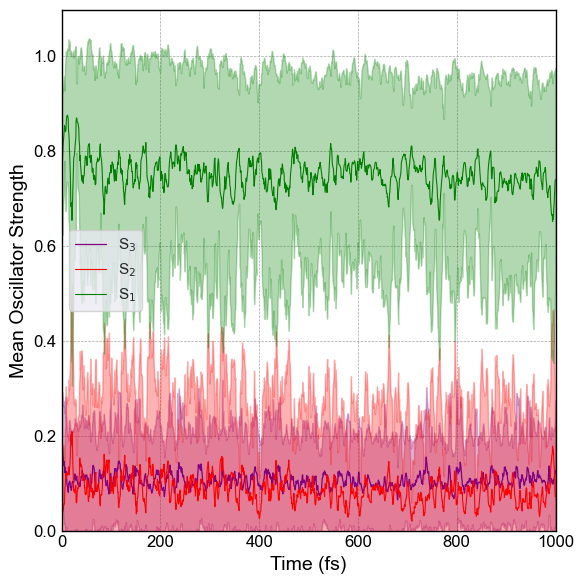

In [63]:
xlabel = "Time (fs)"
ylabel = "Mean Oscillator Strength"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'} 

ax.plot(props_stats['Time'], props_stats['OSS4_1_mean'], color=state_colors[4], lw=0.9, label='S$_3$')
ax.fill_between(props_stats['Time'],
                props_stats['OSS4_1_mean'] - props_stats['OSS4_1_std'],
                props_stats['OSS4_1_mean'] + props_stats['OSS4_1_std'],
                color=state_colors[4], alpha=0.3)
ax.plot(props_stats['Time'], props_stats['OSS3_1_mean'], color=state_colors[3], lw=0.8, label='S$_2$')
ax.fill_between(props_stats['Time'],
                props_stats['OSS3_1_mean'] - props_stats['OSS3_1_std'],
                props_stats['OSS3_1_mean'] + props_stats['OSS3_1_std'],
                color=state_colors[3], alpha=0.3)
ax.plot(props_stats['Time'], props_stats['OSS2_1_mean'], color=state_colors[2], lw=0.8, label='S$_1$')
ax.fill_between(props_stats['Time'],
                props_stats['OSS2_1_mean'] - props_stats['OSS2_1_std'],
                props_stats['OSS2_1_mean'] + props_stats['OSS2_1_std'],
                color=state_colors[2], alpha=0.3)

plt.xlim(0, 1000)
plt.ylim(bottom=0)
plt.tight_layout()
plt.legend()
plt.savefig('plots/'+label+'mean_os.png', dpi=300)
plt.show()

# Mean DeltaE

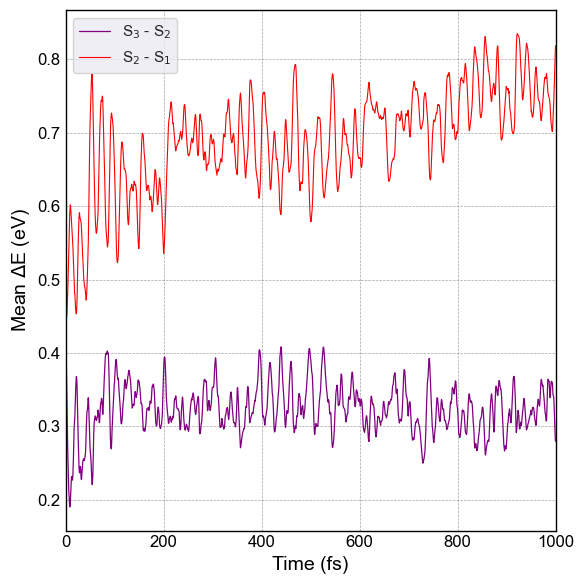

In [64]:
xlabel = "Time (fs)"
ylabel = "Mean $\Delta$E (eV)"

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'} 

 # Plot with standard deviation shaded area
ax.plot(props_stats['Time'], 
        props_stats['DE4_1_mean']-props_stats['DE3_1_mean'], 
        color=state_colors[4], lw=0.9, label='S$_3$ - S$_2$')

ax.plot(props_stats['Time'], 
        props_stats['DE3_1_mean']-props_stats['DE2_1_mean'], 
        color=state_colors[3], lw=0.8, label='S$_2$ - S$_1$')

plt.xlim(0, 1000)
plt.tight_layout()
plt.legend()
plt.savefig('plots/'+label+'mean_energy-diff.png', dpi=300)
plt.show()

# Mean O17-H25 distance

/var/folders/mw/5f7fpfh5163_65rg7hz6m6v00000gn/T/ipykernel_11928/3211869059.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


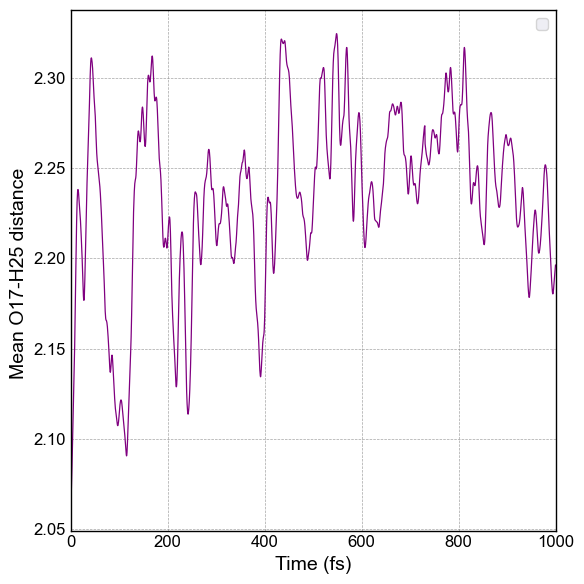

In [65]:
xlabel = "Time (fs)"
ylabel = "Mean O17-H25 distance "

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

# Define colors for each state
state_colors = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple'} 

 # Plot with standard deviation shaded area
ax.plot(coords_r2_stats['Time'], coords_r2_stats['r17_25_mean'], color=state_colors[4], lw=0.9)


plt.xlim(0, 1000)
# plt.ylim(bottom=0)
plt.tight_layout()
plt.legend()
plt.savefig('plots/'+label+'mean_r1725.png', dpi=300)
plt.show()

# Normal mode analysis

In [67]:
xlabel = "Time (fs)"
ylabel = "Normal mode analysis"

nm_cols = [
    col for col in nma.columns
    if col.startswith("NM") and nma[col].abs().max() >= 0.2
]
for col in nm_cols:

    fig, ax = plt.subplots(figsize=(8, 5))

    # White background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)

    ax.tick_params(axis='both', colors='black', direction='in',
                   length=6, width=1.5)
    ax.set_xlabel(xlabel, fontsize=14, color='black')
    ax.set_ylabel(ylabel, fontsize=14, color='black')
    ax.tick_params(labelsize=12)

    # Plot all trajectories for this NM
    for traj in nma['TRAJ'].unique():
        traj_data = nma[nma['TRAJ'] == traj]
        ax.plot(traj_data['Time'], traj_data[col],
                lw=0.8, alpha=0.8)

    ax.set_ylim(0,1)
    ax.set_xlim(0, 1000)
    ax.set_title(col, fontsize=14)

    plt.tight_layout()
    plt.savefig(f"plots/{label}normal-mode_{col}.png", dpi=300)
    plt.close(fig)


In [72]:
print(f"Trajectories that have a large contribution of NM59: {nma.loc[nma['NM59'].abs() > 0.5, 'TRAJ'].unique()}")
print(f"Trajectories that have a large contribution of NM81: {nma.loc[nma['NM81'].abs() > 0.5, 'TRAJ'].unique()}")

print(f"Trajectories with PT: {df_plot.loc[df_plot['r17_25'].abs() < 1.4, 'TRAJ'].unique()}")

Trajectories that have a large contribution of NM59: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]
Trajectories that have a large contribution of NM81: [ 1  2  4  5  7  9 10 11 12 14 15 17 18 23 24 25 27 28 29 31 32 34 35 37
 38 42 43 45 46 47 49]
Trajectories with PT: [ 4  7 17 24 27 30 31 48 49]


In [73]:
# print("Contribution of NM 59 and NM 81 for each trajectory:")

# print('59', '81')
# for traj in df_nma['TRAJ'].unique():    
#     traj_data = df_nma[df_nma['TRAJ'] == traj]
#     max_59 = traj_data['NM59'].abs().max()
#     max_81 = traj_data['NM81'].abs().max()
    
#     print(traj, max_59, max_81)

In [75]:
xlabel = "Time (fs)"
ylabel = "Normal mode analysis"

# Select NM columns with values >= 0.2 somewhere in the dataframe
nm_cols = [
    col for col in nma.columns
    if col.startswith("NM") and nma[col].abs().max() >= 0.2
]

for traj in nma['TRAJ'].unique():

    fig, ax = plt.subplots(figsize=(8, 5))

    # White background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)

    ax.tick_params(axis='both', colors='black', direction='in',
                   length=6, width=1.5)
    ax.set_xlabel(xlabel, fontsize=14, color='black')
    ax.set_ylabel(ylabel, fontsize=14, color='black')
    ax.tick_params(labelsize=12)

    # Select data for this trajectory
    traj_data = nma[nma['TRAJ'] == traj]

    # Plot all NM columns for this trajectory
    for col in nm_cols:
        ax.plot(traj_data['Time'], traj_data[col], lw=0.8, alpha=0.8, label=col)

    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1000)
    ax.set_title(f"Trajectory {traj}", fontsize=14)

    # Optional: show legend if you want to identify NM columns
    ax.legend(fontsize=10, loc='upper right')

    plt.tight_layout()
    plt.savefig(f"plots/normal-mode_traj_{traj}.png", dpi=300)
    plt.close(fig)

/var/folders/mw/5f7fpfh5163_65rg7hz6m6v00000gn/T/ipykernel_11928/1546343662.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


# Mean normal mode analysis

 1 ; 0.1016
 2 ; 0.1116
 3 ; 0.3679
 4 ; 0.0876
 5 ; 0.0310
 6 ; 0.0901
 7 ; 0.2179
 8 ; 0.0664
 9 ; 0.3258
 10 ; 0.0583
 11 ; -0.1852
 12 ; 0.7258
 13 ; 0.0682
 14 ; 0.6335
 15 ; 0.0429
 16 ; -0.0702
 17 ; 0.0318
 18 ; -0.0935
 19 ; 0.0257
 20 ; 0.0002
 21 ; 0.0755
 22 ; 0.0406
 23 ; 0.0402
 24 ; -0.0893
 25 ; 0.0245
 26 ; -0.3746
 27 ; -0.4648
 28 ; -0.4476
 29 ; 0.0233
 30 ; -0.0341


/var/folders/mw/5f7fpfh5163_65rg7hz6m6v00000gn/T/ipykernel_60070/3964236893.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


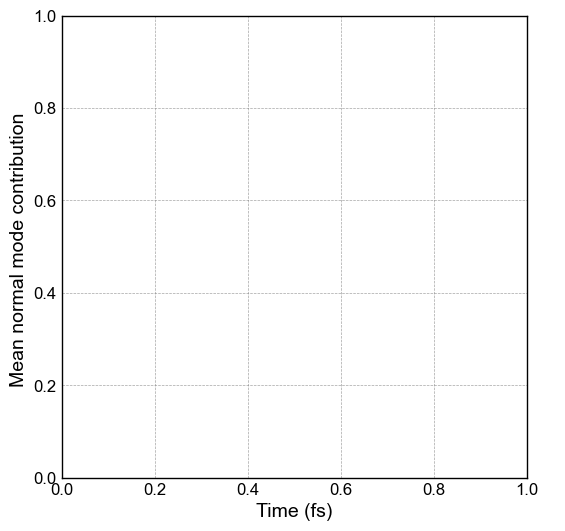

In [11]:
xlabel = "Time (fs)"
ylabel = "Mean normal mode contribution "

fig, ax = plt.subplots()

# White background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

for i in range(7, 37):
    mode = nma.groupby('Time')[f'NM{i}'].agg(['mean', 'std']).reset_index()
    mode.columns = ['Time', f'NM{i}_mean', f'NM{i}_std']
    max_val= mode[f'NM{i}_mean'].max()
    # if np.abs(max_val) < 0.1:
    #     continue
    # if np.abs(max_val) > 2:
    #     continue
    print(f' {i- 6} ; {max_val:.4f}')
    # plt.plot(mode['Time'], mode[f'NM{i}_mean'], label=f'Mean NM{i-6}')
    

ax.tick_params(axis='both', colors='black', direction='in', length=6, width=1.5)
ax.set_xlabel(xlabel, fontsize=14, color='black')
ax.set_ylabel(ylabel, fontsize=14, color='black')
ax.tick_params(labelsize=12)

plt.legend(
    loc = 'center left',
    bbox_to_anchor = (1.02, 0.5), 
    frameon = False
)
plt.savefig(f"plots/{label}mean-normal-mode.png", dpi=300)
